#**A Hybrid Multi-Scale CNN and Bidirectional LSTM Framework with Global Dual-Pooling for Enhanced Humor Detection**

# Load Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("deepcontractor/200k-short-texts-for-humor-detection")

print("Path to dataset files:", path)

100%|██████████| 6.00M/6.00M [00:00<00:00, 79.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/deepcontractor/200k-short-texts-for-humor-detection/versions/1


# Explore Data

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    200000 non-null  object
 1   humor   200000 non-null  bool  
dtypes: bool(1), object(1)
memory usage: 1.7+ MB
None

--- Class Distribution ---
humor
False    100000
True     100000
Name: count, dtype: int64


/tmp/ipykernel_2322/1932952272.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='humor', data=df, palette='viridis') # Changed 'label' to 'humor'


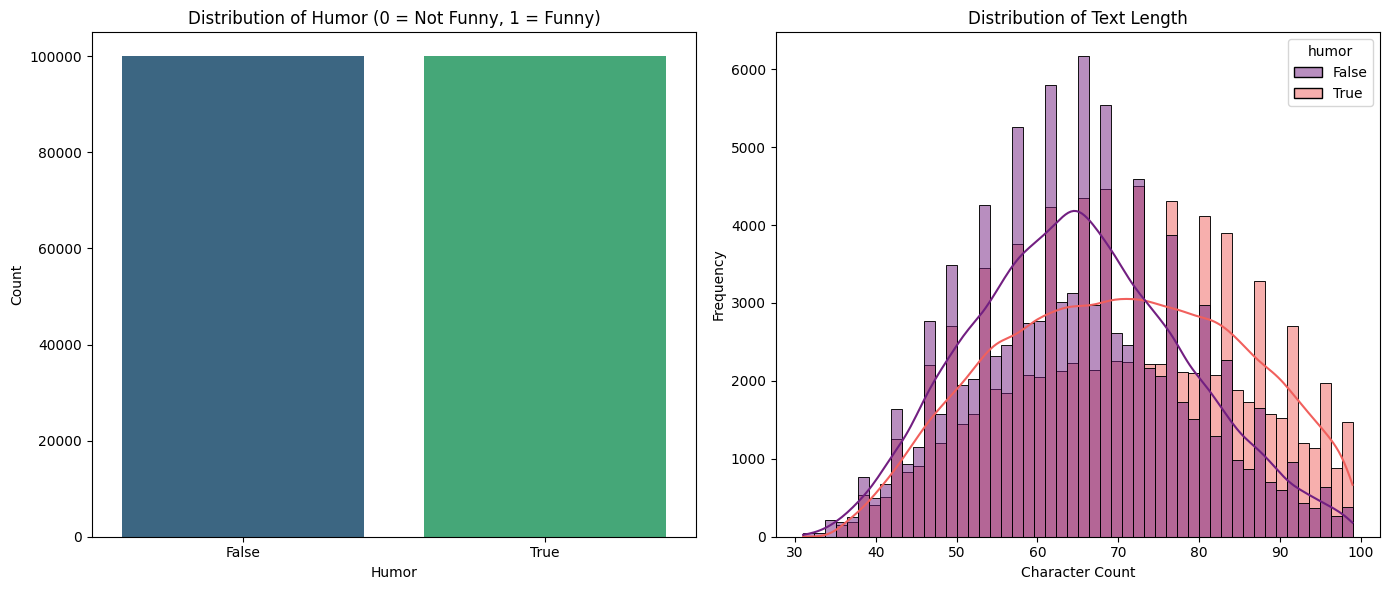

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Locate the file
# Since kagglehub returns a directory, we find the .csv file inside it
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# 2. Load the dataset
df = pd.read_csv(full_path)

# 3. Basic Analysis
print("--- Dataset Info ---")
print(df.info())
print("\n--- Class Distribution ---")
print(df['humor'].value_counts()) # Changed 'label' to 'humor'

# 4. Feature Engineering: Text Length
df['text_length'] = df['text'].apply(len)

# 5. Visualization
plt.figure(figsize=(14, 6))

# Plot 1: Target Distribution (Is it balanced?)
plt.subplot(1, 2, 1)
sns.countplot(x='humor', data=df, palette='viridis') # Changed 'label' to 'humor'
plt.title('Distribution of Humor (0 = Not Funny, 1 = Funny)')
plt.xlabel('Humor') # Changed 'Label' to 'Humor'
plt.ylabel('Count')

# Plot 2: Text Length Distribution by Label
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='text_length', hue='humor', kde=True, bins=50, palette='magma') # Changed 'label' to 'humor'
plt.title('Distribution of Text Length')
plt.xlabel('Character Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Split Dataset

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# ===============================
# Train / Test Split
# ===============================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['text'],
    df['humor'],
    test_size=0.2,
    random_state=42,
    stratify=df['humor']
)

# ===============================
# Train / Validation Split  NEW
# ===============================
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

vocab_size = 25000
max_len = 60

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

# ---- Train ----
X_train = pad_sequences(
    tokenizer.texts_to_sequences(X_train_raw),
    maxlen=max_len,
    padding="post"
)

# ---- Validation ----
X_val = pad_sequences(
    tokenizer.texts_to_sequences(X_val_raw),
    maxlen=max_len,
    padding="post"
)

# ---- Test ----
X_test = pad_sequences(
    tokenizer.texts_to_sequences(X_test_raw),
    maxlen=max_len,
    padding="post"
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (144000, 60)
Val  : (16000, 60)
Test : (40000, 60)


# Build Model

# HYBRID CNN + BiLSTM MODEL

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# ===============================
# HYBRID CNN + BiLSTM MODEL
# ===============================
import tensorflow as tf
from tensorflow.keras import layers, models

def build_hybrid_cnn_lstm(vocab_size, max_len):
    inputs = layers.Input(shape=(max_len,))

    # 1. Embedding with slightly higher dropout for better generalization
    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=128,
        mask_zero=True  # Important for BiLSTM to ignore padding
    )(inputs)
    x = layers.SpatialDropout1D(0.4)(x)

    # 2. Multi-Kernel CNN (Extracting diverse n-gram features)
    conv3 = layers.Conv1D(128, 3, activation="elu", padding="same")(x)
    conv5 = layers.Conv1D(128, 5, activation="elu", padding="same")(x)
    conv7 = layers.Conv1D(128, 7, activation="elu", padding="same")(x)

    x = layers.Concatenate()([conv3, conv5, conv7])
    x = layers.MaxPooling1D(pool_size=2)(x)

    # 3. BiLSTM with Global Pooling
    # We return sequences to capture the importance of every word/feature
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True)
    )(x)

    # Hybrid Pooling: Captures the 'average' vibe and the 'strongest' punchline cue
    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])

    # 4. Dense Head with Batch Normalization
    x = layers.BatchNormalization()(x)
    x = layers.Dense(64, activation="elu")(x)
    x = layers.Dropout(0.5)(x)

    # 5. Classifier (Logits)
    outputs = layers.Dense(1)(x)

    model = models.Model(inputs, outputs)
    return model


# Build Model
model = build_hybrid_cnn_lstm(vocab_size, max_len)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_6' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_7' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_8' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 60, 128)   │  3,200,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 60, 128)   │          0 │ embedding_2[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 60, 128)   │     49,280 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 60, 128)   │     82,048 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 60, 128)   │    114,816 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 60, 384)   │          0 │ conv1d_6[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_7[0][0],   │
│                     │                   │            │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 30, 384)   │          0 │ concatenate_3[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 30, 256)   │    525,312 │ max_pooling1d_2[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ bidirectional_2[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ bidirectional_2[… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 512)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ concatenate_4[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │     32,832 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,006,401 (15.28 MB)

 Trainable params: 4,005,377 (15.28 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
# Use a slightly lower starting LR for smoother validation curves
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=3e-5,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    # Label smoothing 0.1 helps the model stay "humble" and generalize
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True, label_smoothing=0.1),
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# Train Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "cnn_lstm_best.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop, reduce_lr, checkpoint],
    shuffle=True
)

Epoch 1/15
2249/2250 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7396 - auc: 0.7857 - loss: 0.5360 - precision: 0.8210 - recall: 0.6009
Epoch 1: val_auc improved from None to 0.92968, saving model to cnn_lstm_best.keras

Epoch 1: finished saving model to cnn_lstm_best.keras
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.8259 - auc: 0.8701 - loss: 0.4439 - precision: 0.9023 - recall: 0.7309 - val_accuracy: 0.9009 - val_auc: 0.9297 - val_loss: 0.3367 - val_precision: 0.9695 - val_recall: 0.8278 - learning_rate: 3.0000e-05
Epoch 2/15
2248/2250 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9060 - auc: 0.9345 - loss: 0.3504 - precision: 0.9523 - recall: 0.8556
Epoch 2: val_auc improved from 0.92968 to 0.95185, saving model to cnn_lstm_best.keras

Epoch 2: finished saving model to cnn_lstm_best.keras
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - accuracy: 0.9109 - auc: 0.9381 - loss: 0.3429 - precision: 0.9538 - recall: 0.8636 - val_accuracy: 0.9299 - val_auc: 0.9518 - val

# Save Model

In [ ]:
# ===============================
# SAVE MODEL
# ===============================
model.save("Hybrid_CNN_LSTM.keras")

print("Model saved successfully")

Model saved successfully


In [8]:
import tensorflow as tf

# ===============================
# LOAD MODEL
# ===============================
model = tf.keras.models.load_model("Hybrid_CNN_LSTM.keras")

print("Model loaded successfully")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_6' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_7' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_8' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model loaded successfully


In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

#  Confusion Matrix

In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


plt.rcParams.update({
    'font.size': 16,
    'font.weight': 'bold',
    'axes.titlesize': 20,
    'axes.titleweight': 'bold',
    'axes.labelsize': 18,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})


y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)


print("\n" + "="*60)
print("CLASSIFICATION REPORT ")
print("="*60)
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Funny', 'Funny'],
    digits=4
))

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step

CLASSIFICATION REPORT 
              precision    recall  f1-score   support

   Not Funny     0.9375    0.9729    0.9549     20000
       Funny     0.9718    0.9352    0.9531     20000

    accuracy                         0.9540     40000
   macro avg     0.9547    0.9540    0.9540     40000
weighted avg     0.9547    0.9540    0.9540     40000



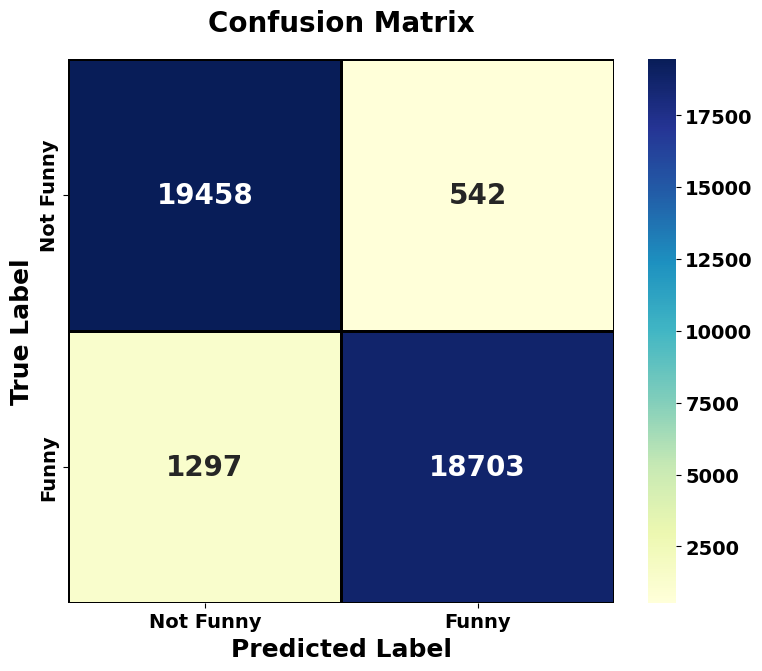

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 7))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    annot_kws={"size":20, "weight":"bold"},
    linewidths=2,
    linecolor='black',
    cbar=True,
    xticklabels=['Not Funny', 'Funny'],
    yticklabels=['Not Funny', 'Funny']
)

plt.title('Confusion Matrix', pad=20)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.xticks(weight='bold')
plt.yticks(weight='bold')

plt.tight_layout()
plt.show()

# Model History

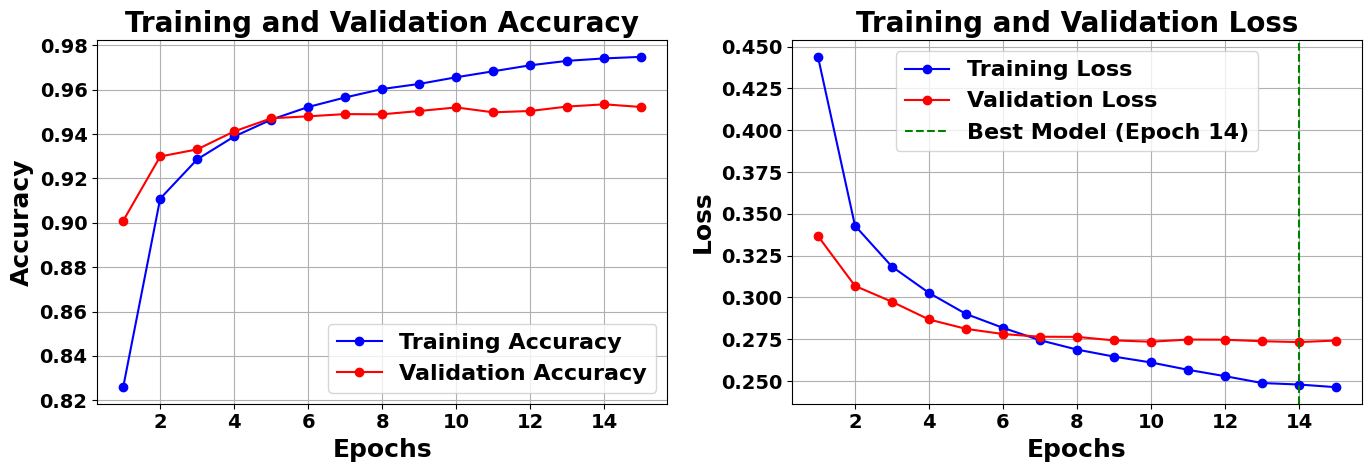

In [11]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    # Mark the best epoch (Restored Weights)
    best_epoch = val_loss.index(min(val_loss)) + 1
    plt.axvline(x=best_epoch, color='g', linestyle='--', label=f'Best Model (Epoch {best_epoch})')

    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

# Performance Metrics

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, matthews_corrcoef, mean_squared_error

# 1. Get raw probabilities and binary predictions
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Extract Confusion Matrix components
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# 3. Calculate Metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
error_rate = (fp + fn) / (tp + tn + fp + fn)
mcc = matthews_corrcoef(y_test, y_pred)

# 4. Display Results
print(f"{'Metric':<15} | {'Value':<10}")
print("-" * 30)
print(f"{'Accuracy':<15} | {accuracy:.4f}")
print(f"{'Precision':<15} | {precision:.4f}")
print(f"{'Recall':<15} | {recall:.4f}")
print(f"{'Specificity':<15} | {specificity:.4f}")
print(f"{'Error Rate':<15} | {error_rate:.4f}")
print(f"{'MCC':<15} | {mcc:.4f}")

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
Metric          | Value     
------------------------------
Accuracy        | 0.9540
Precision       | 0.9718
Recall          | 0.9352
Specificity     | 0.9729
Error Rate      | 0.0460
MCC             | 0.9087


# Prediction

In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_humor(texts, model, tokenizer, max_len=60):

    #  Text → sequence
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(
        sequences,
        maxlen=max_len,
        padding='post',
        truncating='post'
    )

    #  Predict LOGITS
    logits = model.predict(padded, verbose=0)

    #  Convert logits → probabilities
    probs = tf.sigmoid(logits).numpy()

    #  Display
    print(f"{'Prediction':<12} | {'Confidence':<10} | Text")
    print("-"*80)

    for text, p in zip(texts, probs):

        prob = float(p[0])
        label = "Humor" if prob > 0.5 else "NOT Humor"
        confidence = prob if prob > 0.5 else (1 - prob)

        print(f"{label:<12} | {confidence:6.2%} | {text}")

# --- 2. Test Suite ---
custom_test_jokes = [
    "I'm on a seafood diet. I see food and I eat it.",              # Classic Pun
    "The internal combustion engine was invented in 1876.",        # Plain Fact
    "Parallel lines have so much in common. It's a shame they'll never meet.", # Logical Joke
    "The cat sat on the mat and looked at the wall.",              # Random Sentence
    "My wife told me to stop impersonating a flamingo. I had to put my foot down.", # Wordplay
    "The weather today is cloudy with a chance of rain."           # Forecast
]

# Run the prediction
predict_humor(custom_test_jokes, model, tokenizer)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_6' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_7' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_8' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Prediction   | Confidence | Text
--------------------------------------------------------------------------------
Humor        | 94.31% | I'm on a seafood diet. I see food and I eat it.
NOT Humor    | 61.73% | The internal combustion engine was invented in 1876.
Humor        | 94.22% | Parallel lines have so much in common. It's a shame they'll never meet.
NOT Humor    | 92.41% | The cat sat on the mat and looked at the wall.
Humor        | 95.13% | My wife told me to stop impersonating a flamingo. I had to put my foot down.
NOT Humor    | 81.01% | The weather today is cloudy with a chance of rain.
